<a href="https://colab.research.google.com/github/rishitharee24-create/maths/blob/main/Unit5q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

v(t)      = t**2 + t
v_even(t) = t**2   (even function -> cosine series)
v_odd(t)  = t   (odd function  -> sine series)

Cosine series of v_even:
a0 = 2*pi**2/3   a_n = 4*(-1)**n/n**2  (b_n = 0, confirms even -> cosine only)

Sine series of v_odd:
b_n = -2*(-1)**n/n  (a_n = 0, confirms odd -> sine only)


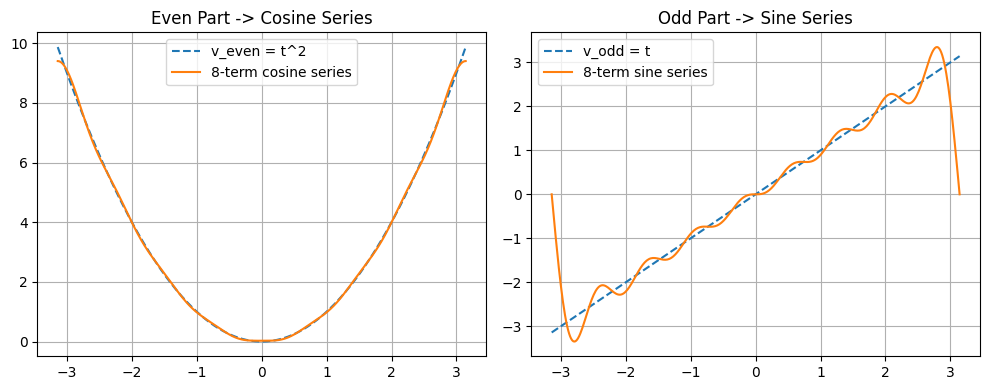

In [31]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.symbols('t')
n = sp.symbols('n', positive=True, integer=True)
L = sp.pi
v = t + t**2  # original waveform on (-pi, pi)

# Even and odd decomposition
v_even = sp.simplify((v + v.subs(t, -t)) / 2)
v_odd  = sp.simplify((v - v.subs(t, -t)) / 2)
print("v(t)      =", v)
print("v_even(t) =", v_even, "  (even function -> cosine series)")
print("v_odd(t)  =", v_odd,  "  (odd function  -> sine series)")

# Fourier (cosine) series of even part
a0 = (1/L) * sp.integrate(v_even, (t, -L, L))
an = sp.simplify((1/L) * sp.integrate(v_even * sp.cos(n*t), (t, -L, L)))
print("\nCosine series of v_even:")
print("a0 =", a0, "  a_n =", an, " (b_n = 0, confirms even -> cosine only)")

# Fourier (sine) series of odd part
bn = sp.simplify((1/L) * sp.integrate(v_odd * sp.sin(n*t), (t, -L, L)))
print("\nSine series of v_odd:")
print("b_n =", bn, " (a_n = 0, confirms odd -> sine only)")

# Reconstruct and plot using first 8 terms
N = 8
tv = np.linspace(-np.pi, np.pi, 400)
v_e_recon = np.full_like(tv, float(a0)/2)
v_o_recon = np.zeros_like(tv)
an_f = sp.lambdify(n, an, 'numpy')
bn_f = sp.lambdify(n, bn, 'numpy')
for k in range(1, N+1):
    v_e_recon += an_f(k) * np.cos(k*tv)
    v_o_recon += bn_f(k) * np.sin(k*tv)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(tv, tv**2, '--', label='v_even = t^2')
axs[0].plot(tv, v_e_recon, label=f'{N}-term cosine series')
axs[0].set_title('Even Part -> Cosine Series'); axs[0].legend(); axs[0].grid(True)

axs[1].plot(tv, tv, '--', label='v_odd = t')
axs[1].plot(tv, v_o_recon, label=f'{N}-term sine series')
axs[1].set_title('Odd Part -> Sine Series'); axs[1].legend(); axs[1].grid(True)

plt.tight_layout()
plt.savefig('p27_even_odd_decomposition.png', dpi=120)
plt.show()














